# Section 4: Alternate K-Means Algorithm — Full Analysis

In this section we implement and analyze an **alternate k-means variant** that departs from the
standard reassignment strategy: instead of reassigning every point on each iteration, it identifies
the **single furthest point** in each cluster and only reassigns that point if a closer centroid
exists. This conservative approach is compared against three other algorithms:

| Algorithm | Initialization | Iteration Strategy |
|-----------|---------------|--------------------|
| **Custom (ESPI + Drift)** | Deterministic range-based (ESPI) | Drift-based boundary skipping |
| **Alternate (Furthest-Point)** | Random | Only reassign furthest point per cluster |
| **Sklearn (Random)** | Random | Standard full reassignment |
| **Sklearn (K-Means++)** | K-Means++ | Standard full reassignment |

We evaluate all four on three datasets (Iris, AI Index, Earthquakes) across k = {2, 5, 10, 20},
examining clustering quality (SSE), convergence behavior, assignment stability, and runtime.

In [1]:
# ── Cell 2: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, kmeans_plusplus

from kmeans_alternate import KMeansAlternate
from kmeans_custom import KMeansCustom

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# ── Cell 3: Load and preprocess datasets ─────────────────────────────────────
scaler = StandardScaler()

# D1 — Iris
iris_df = pd.read_csv('data/iris.csv')
iris_df = iris_df.drop(columns=['species'])
iris_data = scaler.fit_transform(iris_df.values)

# D2 — AI Index
ai_df = pd.read_csv('data/ai_index.csv')
ai_df = ai_df.select_dtypes(include=[np.number]).dropna()
ai_data = scaler.fit_transform(ai_df.values)

# D3 — Earthquakes
eq_df = pd.read_csv('data/earthquakes.csv')
eq_df = eq_df[['magnitude', 'depth', 'latitude', 'longitude']].dropna()
eq_data = scaler.fit_transform(eq_df.values)

datasets = {
    'Iris (D1)': iris_data,
    'AI Index (D2)': ai_data,
    'Earthquakes (D3)': eq_data
}

for name, data in datasets.items():
    print(f'{name}: {data.shape}')

Iris (D1): (150, 4)
AI Index (D2): (62, 8)
Earthquakes (D3): (1137, 4)


In [3]:
# ── Cell 4: StandardKMeansTracker ────────────────────────────────────────────
class StandardKMeansTracker:
    """
    Textbook k-means with per-iteration SSE and reassignment tracking.
    Supports 'random' and 'k-means++' initialization.
    """

    def __init__(self, k, init='random', max_iterations=100, random_state=42):
        self.k = k
        self.init = init
        self.max_iterations = max_iterations
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.sse_history = []
        self.reassigned_history = []
        self.n_iterations = 0

    def _init_centroids(self, data):
        if self.init == 'k-means++':
            centroids, _ = kmeans_plusplus(data, n_clusters=self.k,
                                          random_state=self.random_state)
            return centroids
        else:  # 'random'
            rng = np.random.RandomState(self.random_state)
            indices = rng.choice(len(data), self.k, replace=False)
            return data[indices].copy()

    @staticmethod
    def _assign_all(data, centroids):
        # Vectorised: (n, 1, d) - (1, k, d) => (n, k, d) => (n, k) => (n,)
        diffs = data[:, np.newaxis, :] - centroids[np.newaxis, :, :]
        dists = np.sqrt(np.sum(diffs ** 2, axis=2))
        return np.argmin(dists, axis=1)

    @staticmethod
    def _compute_sse(data, labels, centroids, k):
        sse = 0.0
        for i in range(k):
            cluster_pts = data[labels == i]
            if len(cluster_pts) > 0:
                sse += np.sum((cluster_pts - centroids[i]) ** 2)
        return sse

    def fit(self, data):
        self.sse_history = []
        self.reassigned_history = []
        self.n_iterations = 0

        # Initialise centroids
        self.centroids = self._init_centroids(data)

        # Initial full assignment
        self.labels = self._assign_all(data, self.centroids)

        for _ in range(self.max_iterations):
            # Update centroids
            new_centroids = np.empty_like(self.centroids)
            for i in range(self.k):
                cluster_pts = data[self.labels == i]
                if len(cluster_pts) == 0:
                    new_centroids[i] = self.centroids[i]
                else:
                    new_centroids[i] = cluster_pts.mean(axis=0)
            self.centroids = new_centroids

            # Reassign all points
            new_labels = self._assign_all(data, self.centroids)
            reassigned = int(np.sum(new_labels != self.labels))

            # SSE
            sse = self._compute_sse(data, new_labels, self.centroids, self.k)

            self.sse_history.append(sse)
            self.reassigned_history.append(reassigned)
            self.n_iterations += 1

            if reassigned == 0:
                break

            self.labels = new_labels

        return self

print('StandardKMeansTracker defined.')

StandardKMeansTracker defined.


## 4.2.1 Clustering Results for k = {2, 5, 10, 20}

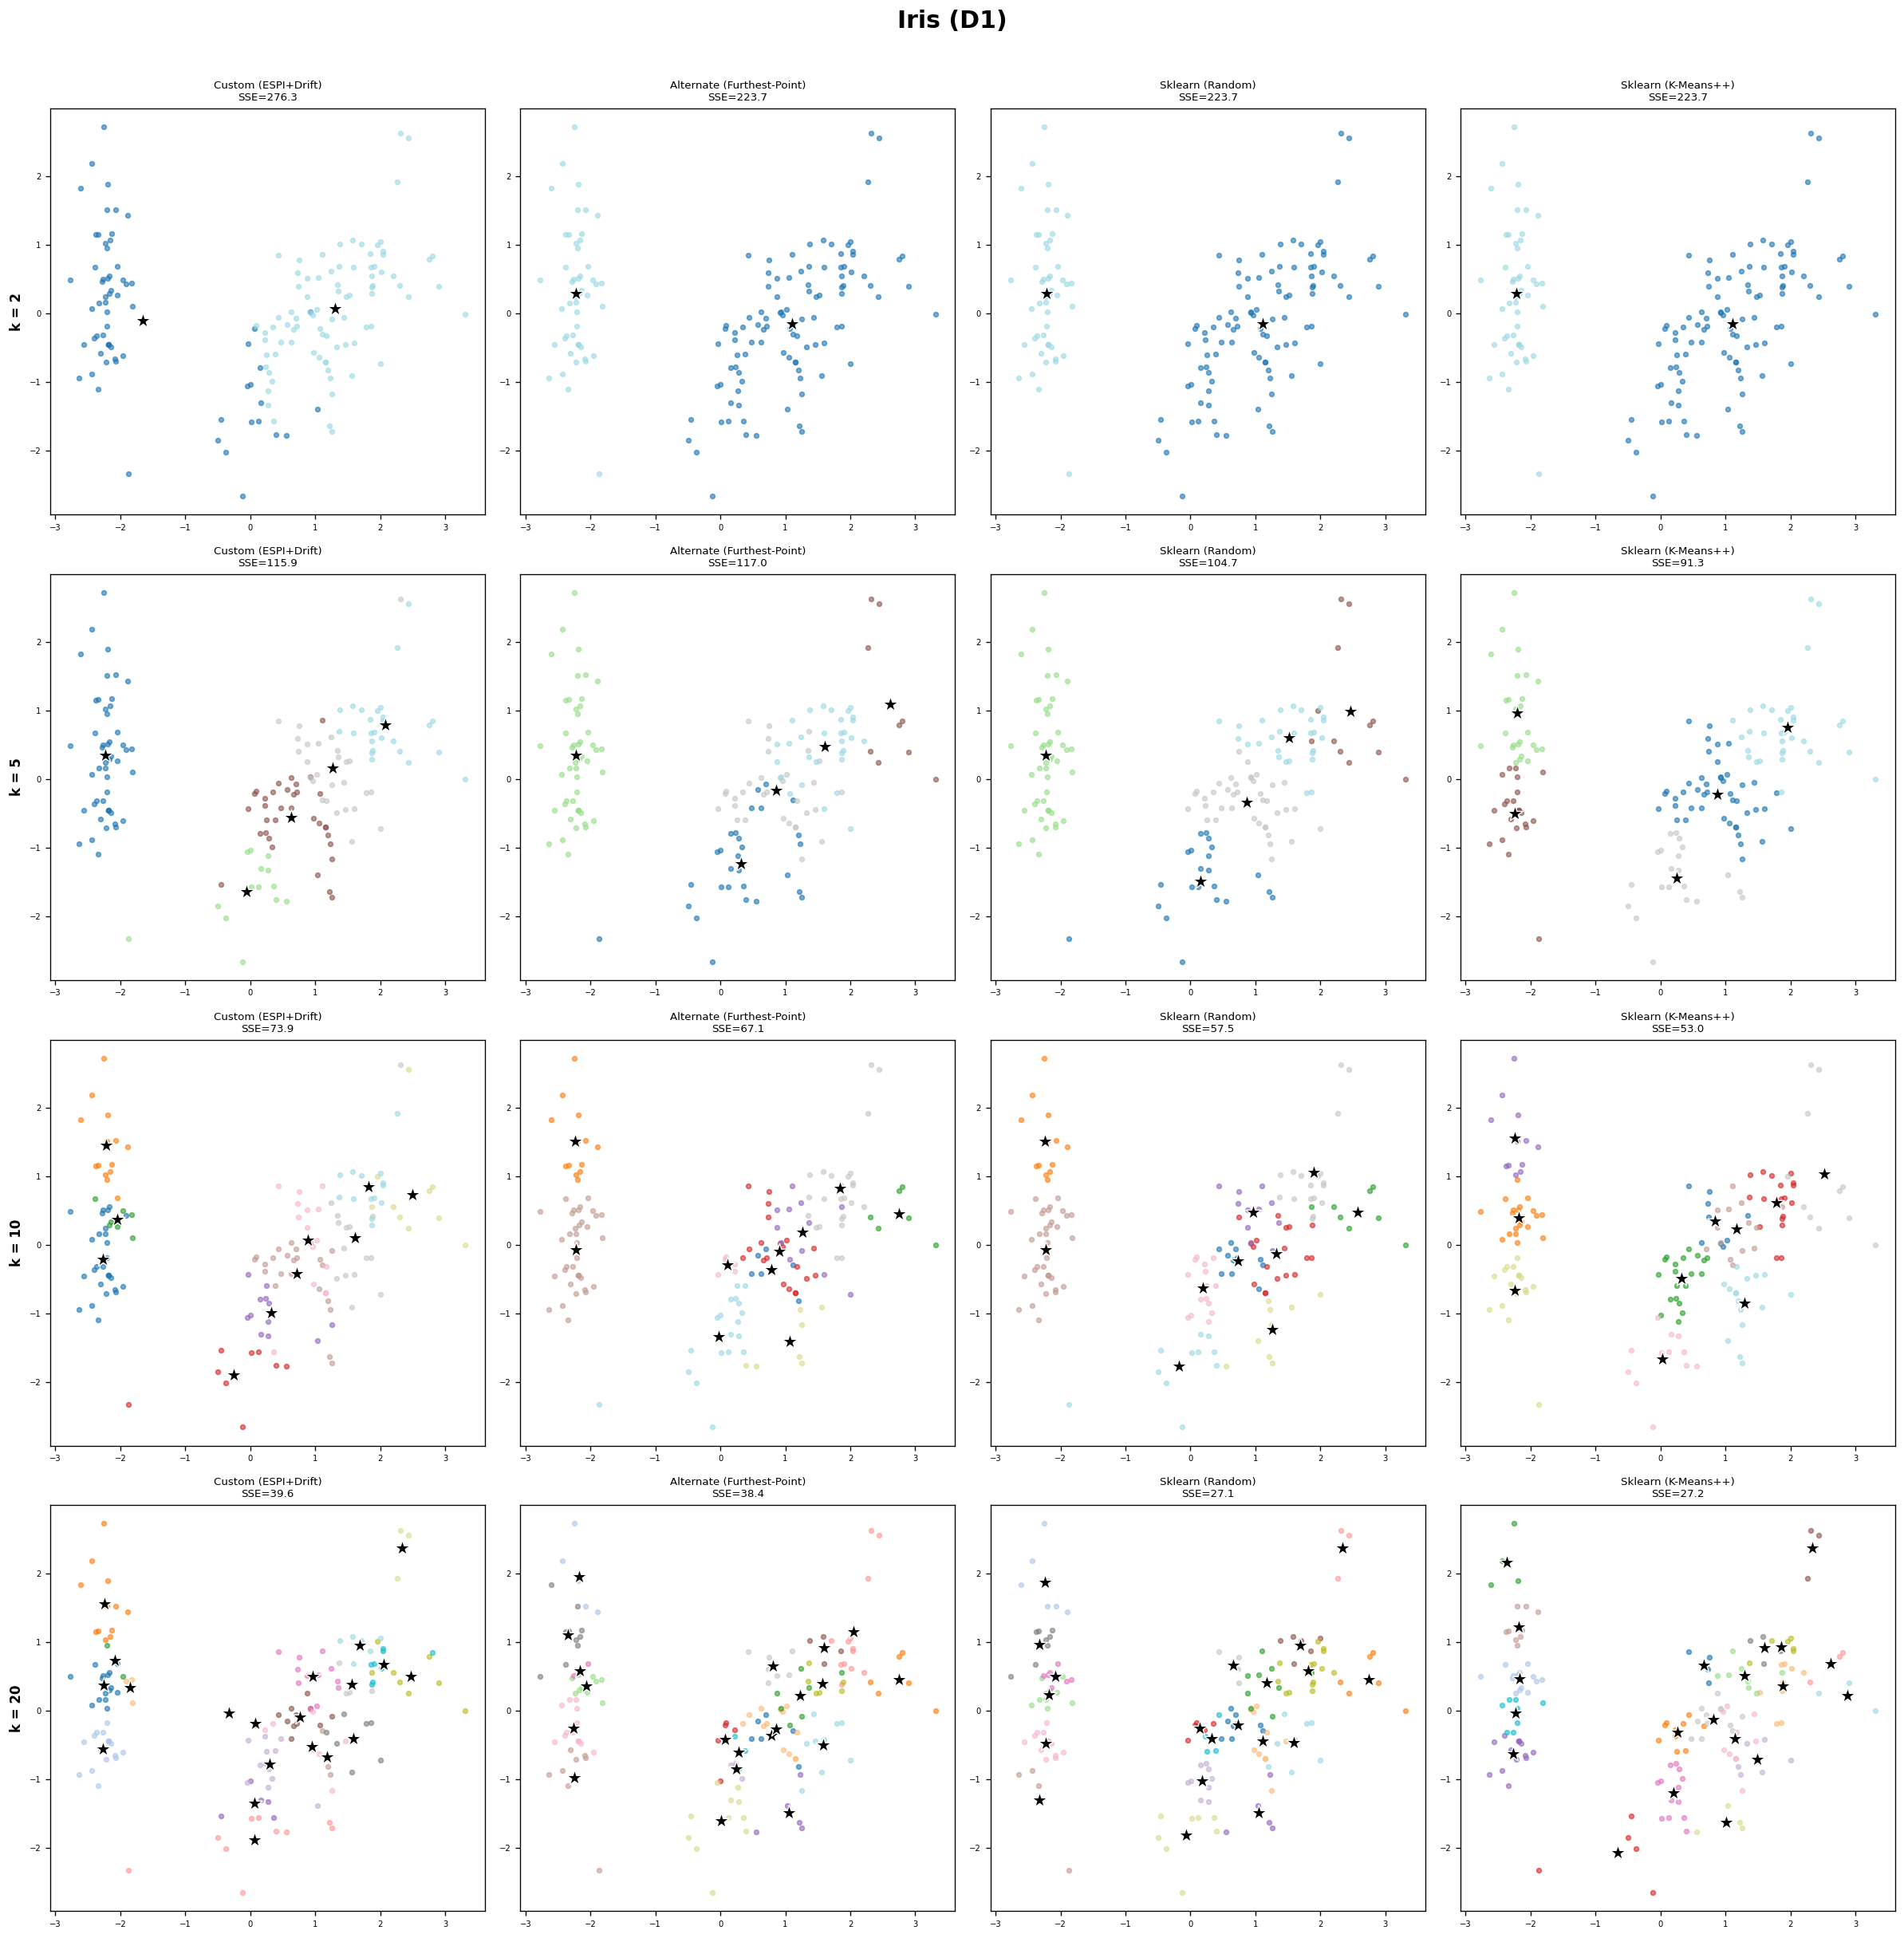

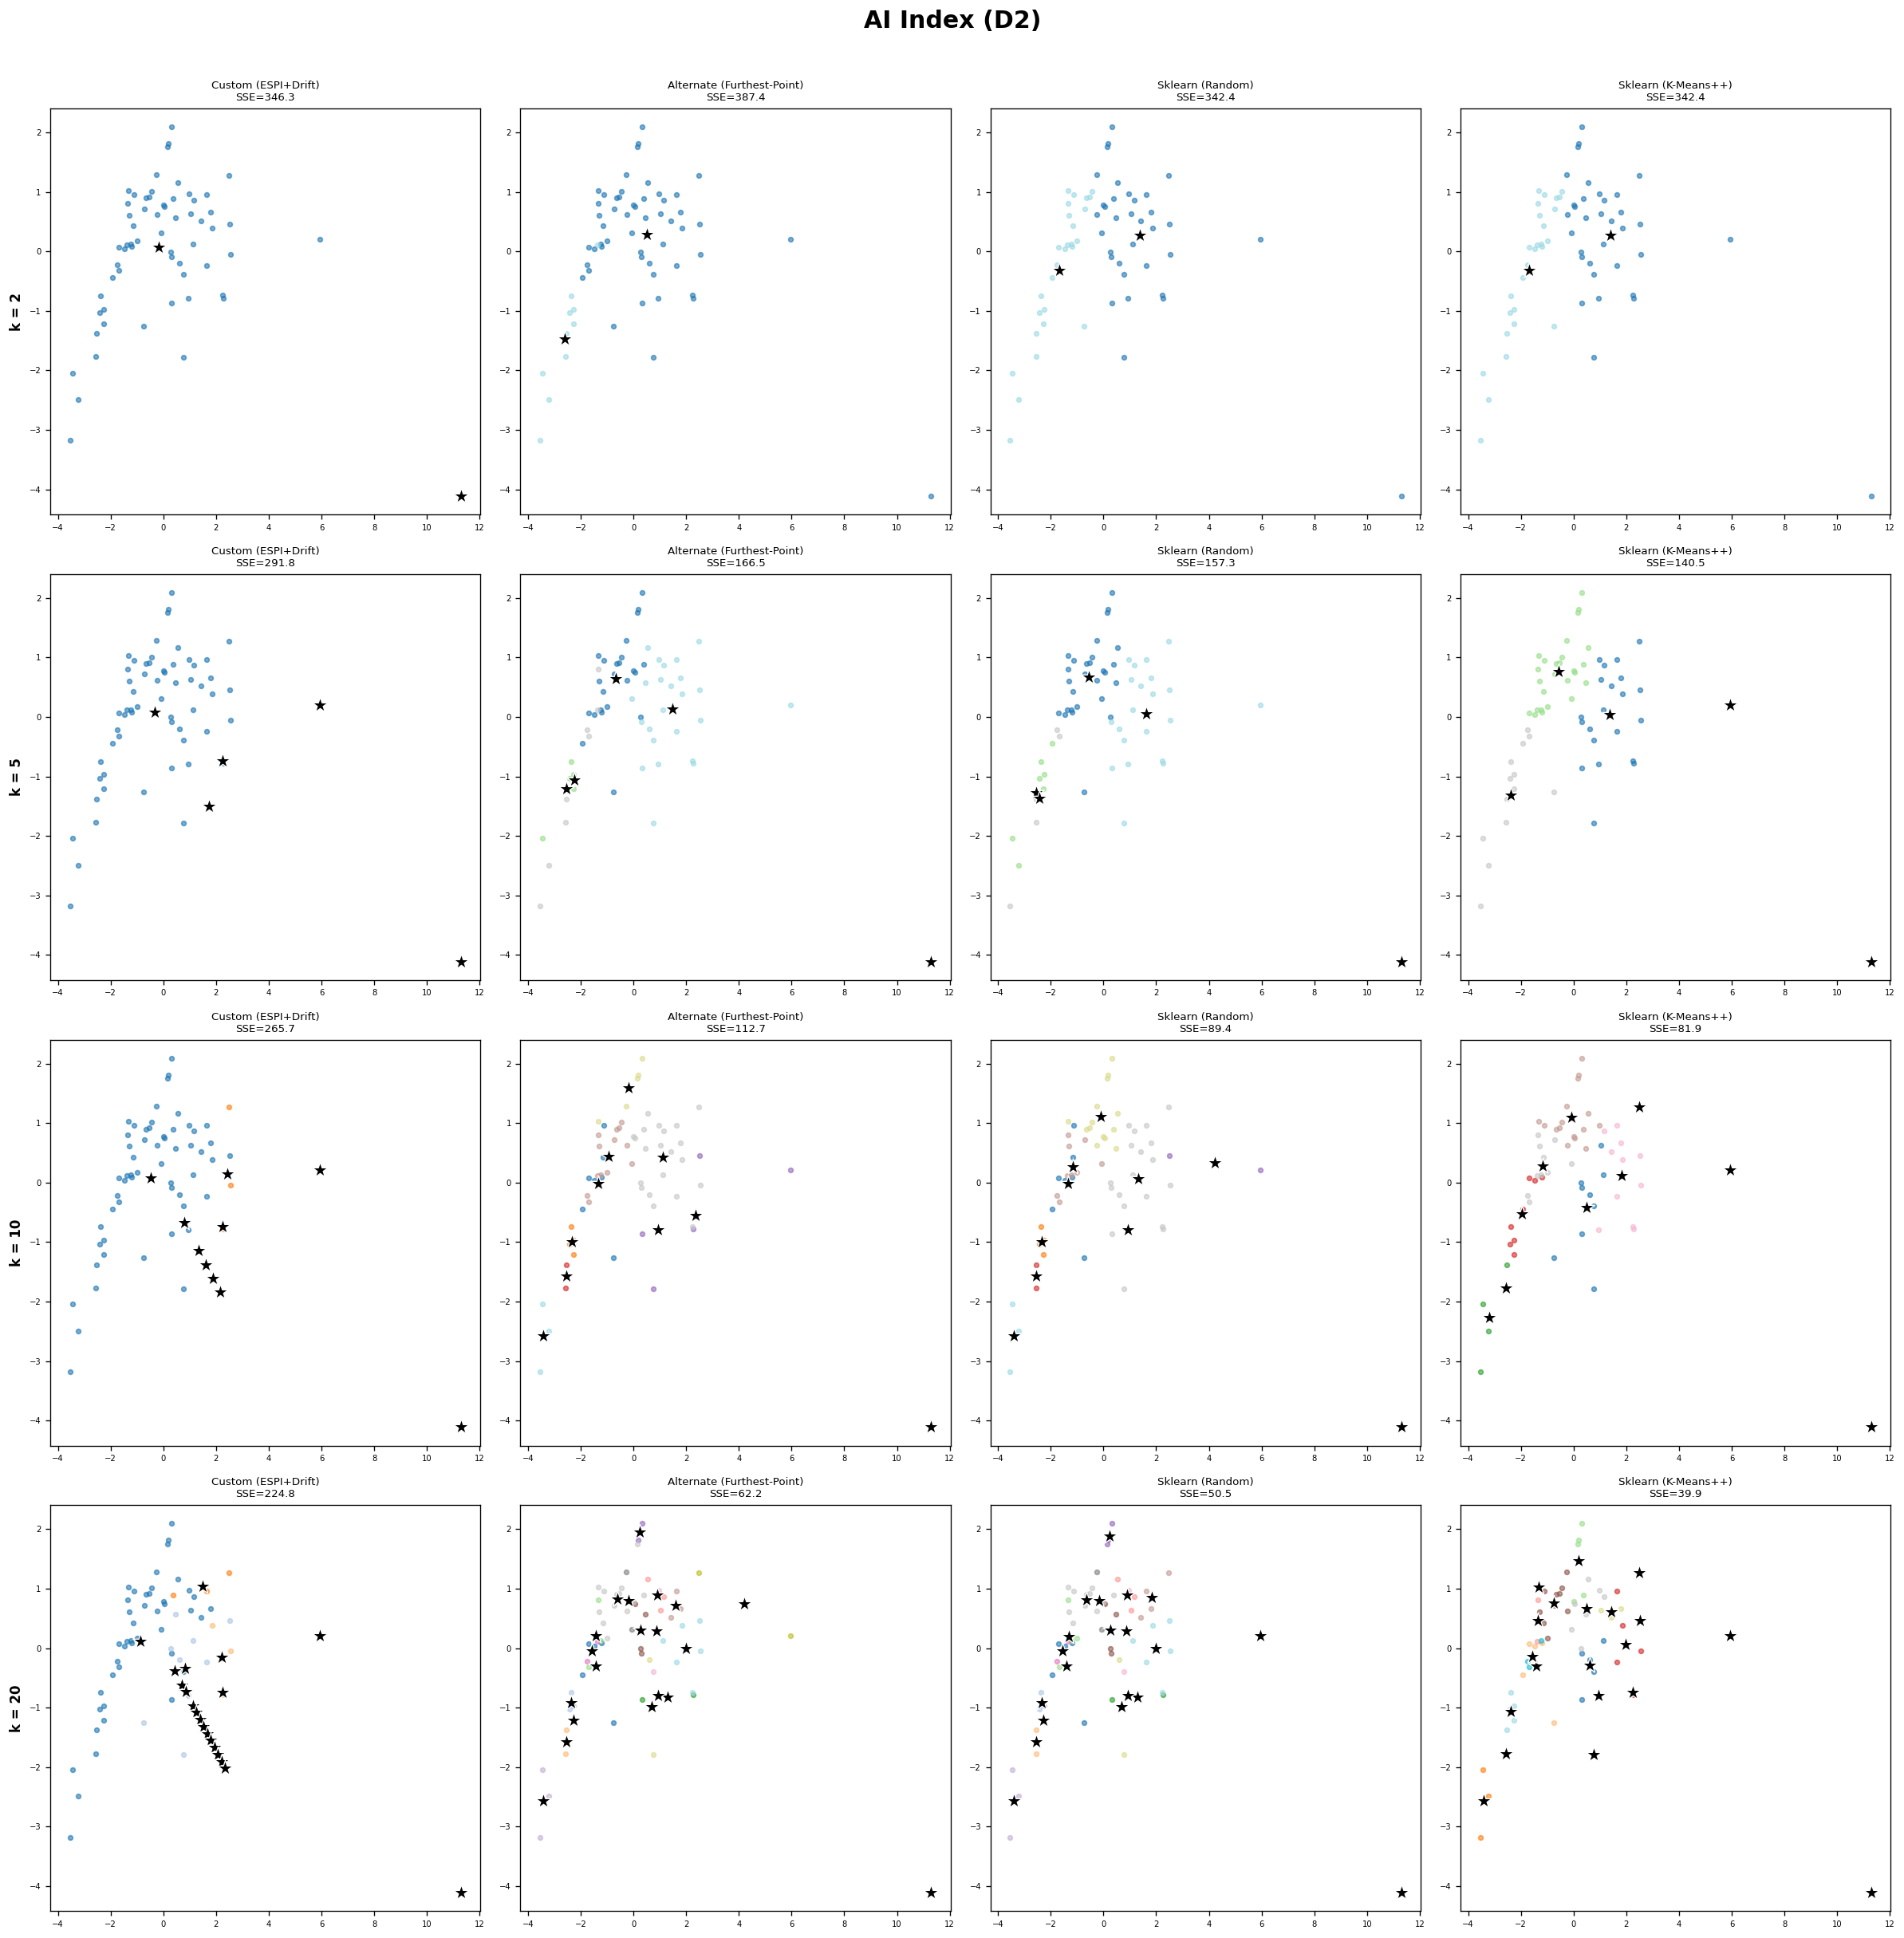

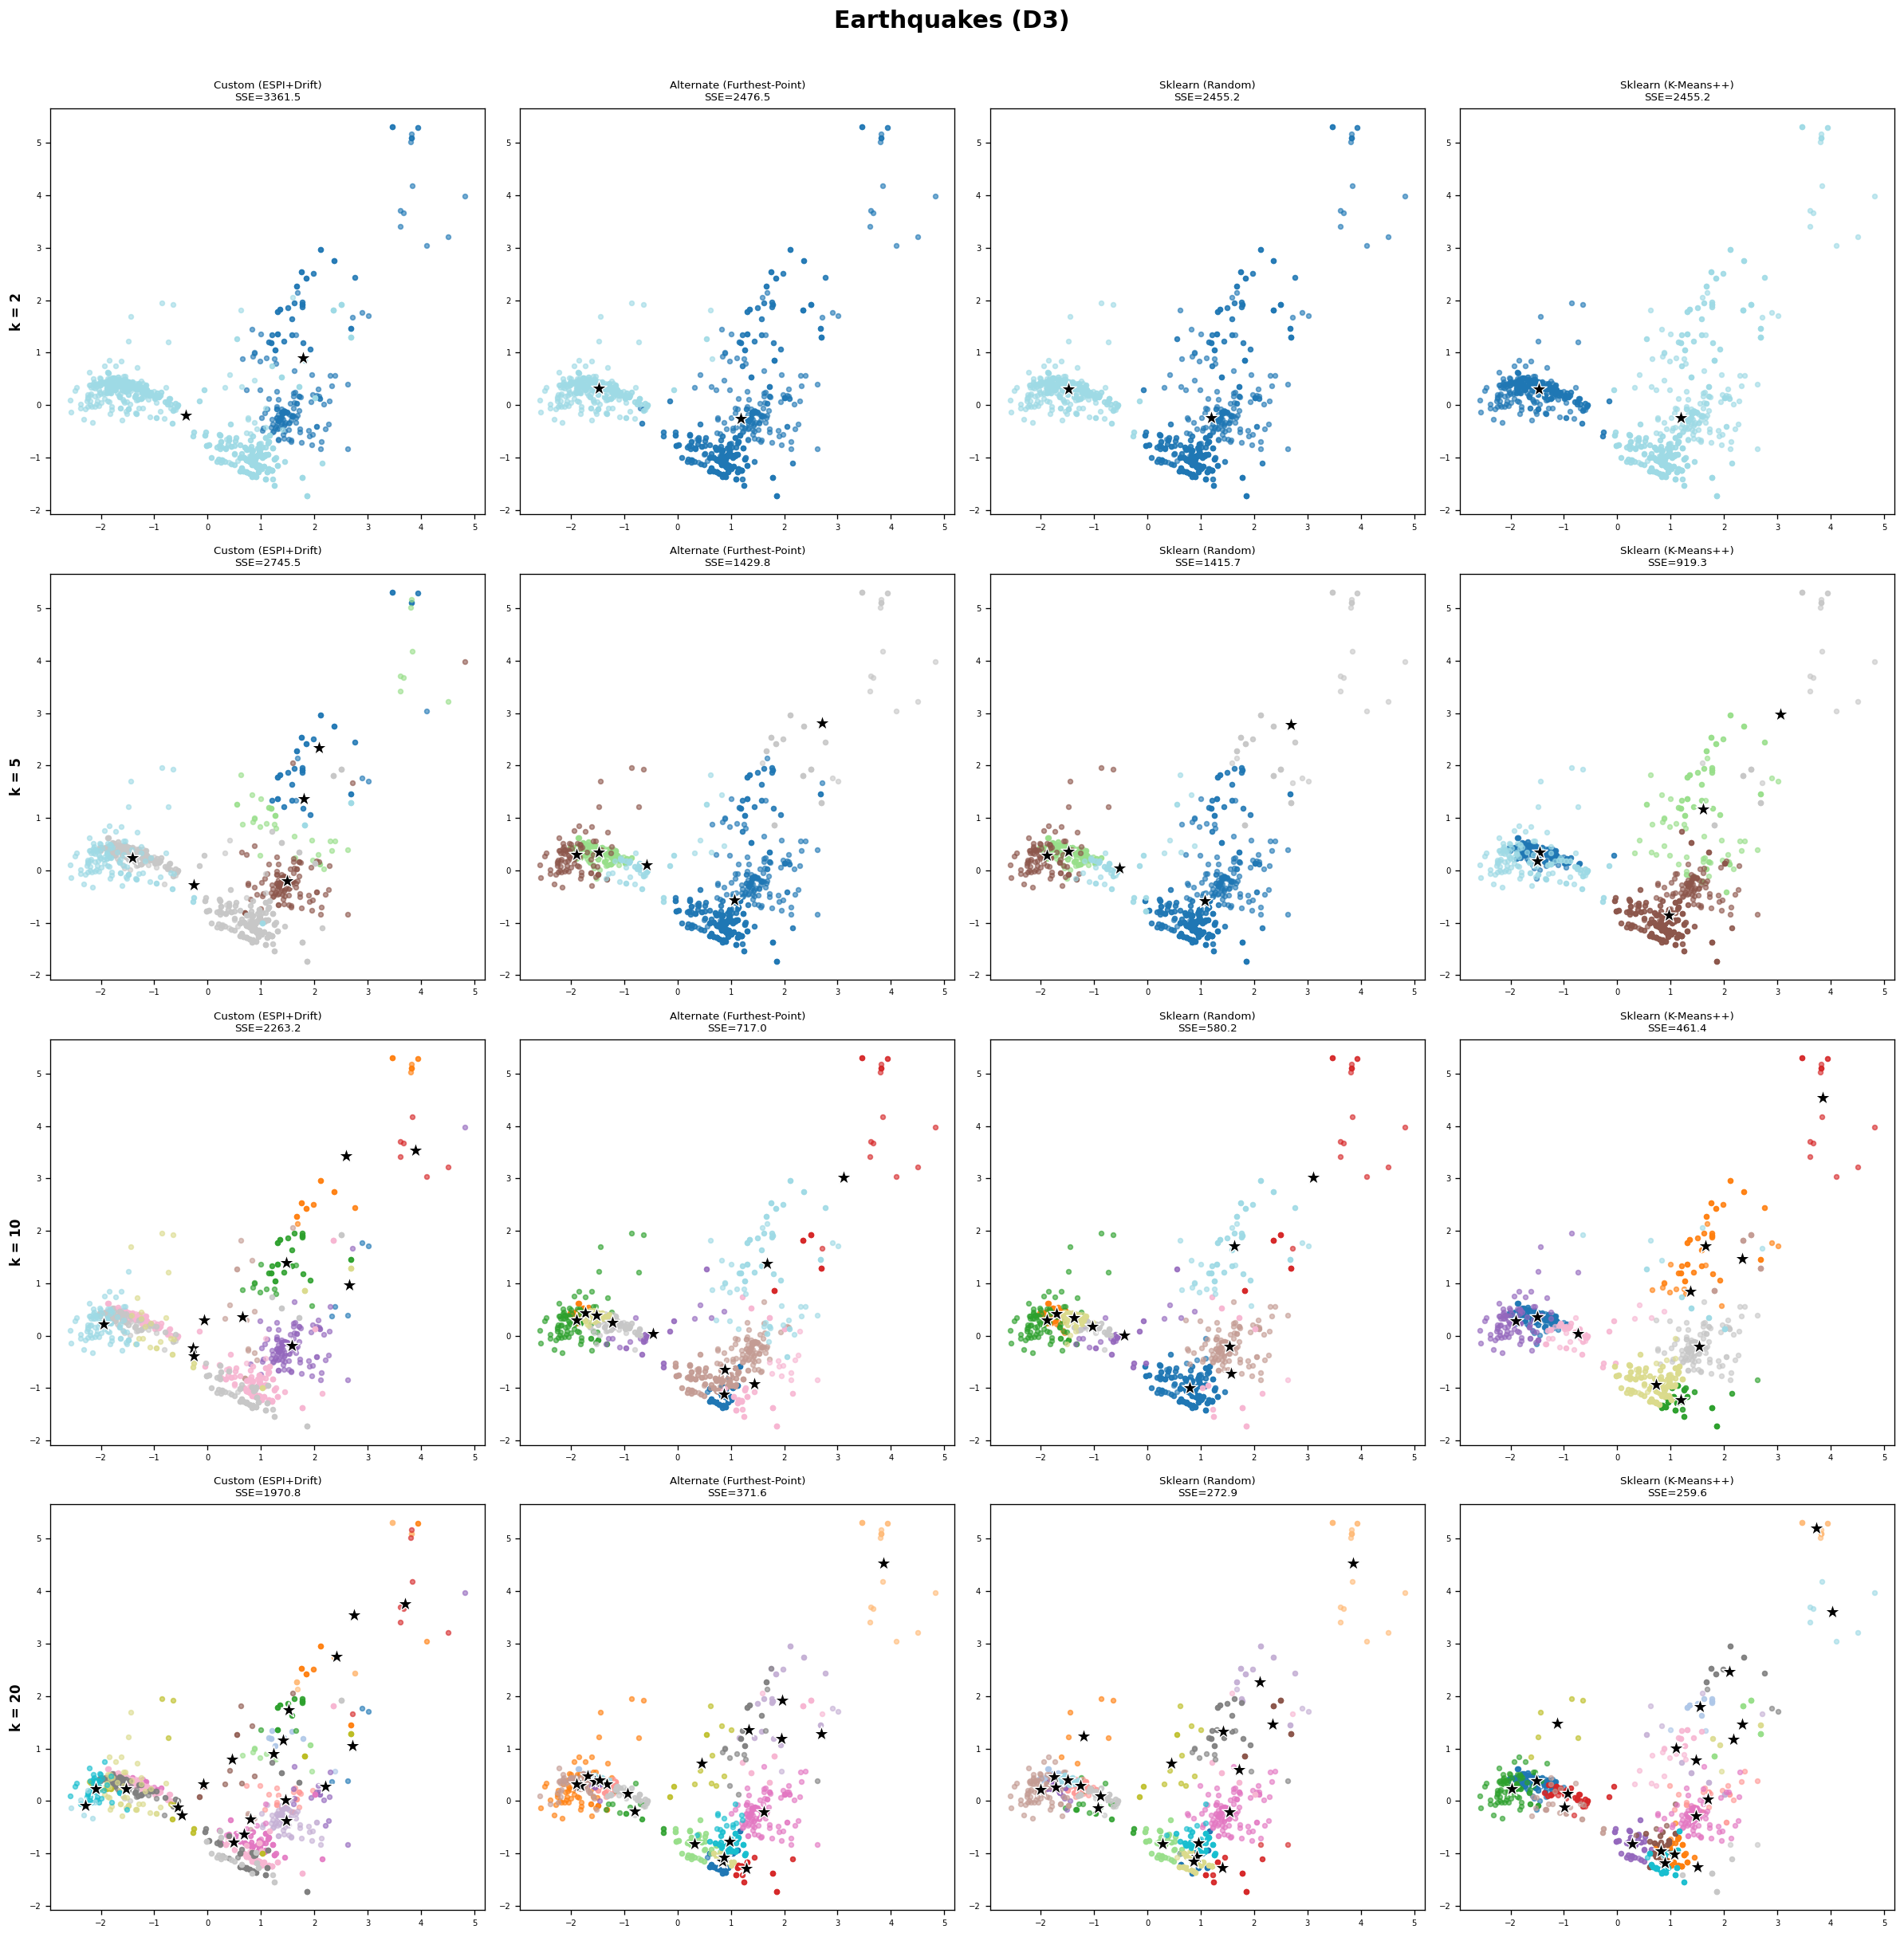

In [4]:
# ── Cell 6: PCA scatter plots — 4 rows (k) x 4 cols (algorithm) per dataset ─
k_values = [2, 5, 10, 20]
algo_names = [
    'Custom (ESPI+Drift)',
    'Alternate (Furthest-Point)',
    'Sklearn (Random)',
    'Sklearn (K-Means++)'
]
algo_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Store results for later cells
all_results = {}  # key: (dataset_name, k, algo_idx) -> dict with model info

for ds_name, data in datasets.items():
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)

    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    fig.suptitle(ds_name, fontsize=18, fontweight='bold', y=1.01)

    for row_idx, k in enumerate(k_values):
        # --- Algorithm 0: Custom (ESPI + Drift) ---
        model_custom = KMeansCustom(k=k, max_iterations=100, epsilon=1e-4)
        model_custom.fit(data)
        all_results[(ds_name, k, 0)] = {
            'labels': model_custom.labels.copy(),
            'centroids': model_custom.centroids.copy(),
            'sse_history': list(model_custom.sse_history),
            'reassigned_history': list(model_custom.reassigned_history),
            'n_iterations': model_custom.n_iterations,
            'final_sse': model_custom.sse_history[-1] if model_custom.sse_history else 0
        }

        # --- Algorithm 1: Alternate (Furthest-Point) ---
        np.random.seed(42)
        model_alt = KMeansAlternate(k=k, max_iterations=100)
        model_alt.fit(data)
        all_results[(ds_name, k, 1)] = {
            'labels': model_alt.labels.copy(),
            'centroids': model_alt.centroids.copy(),
            'sse_history': list(model_alt.sse_history),
            'reassigned_history': list(model_alt.reassigned_history),
            'n_iterations': model_alt.n_iterations,
            'final_sse': model_alt.sse_history[-1] if model_alt.sse_history else 0
        }

        # --- Algorithm 2: Sklearn Random ---
        model_rnd = StandardKMeansTracker(k=k, init='random', random_state=42)
        model_rnd.fit(data)
        all_results[(ds_name, k, 2)] = {
            'labels': model_rnd.labels.copy(),
            'centroids': model_rnd.centroids.copy(),
            'sse_history': list(model_rnd.sse_history),
            'reassigned_history': list(model_rnd.reassigned_history),
            'n_iterations': model_rnd.n_iterations,
            'final_sse': model_rnd.sse_history[-1] if model_rnd.sse_history else 0
        }

        # --- Algorithm 3: Sklearn K-Means++ ---
        model_kpp = StandardKMeansTracker(k=k, init='k-means++', random_state=42)
        model_kpp.fit(data)
        all_results[(ds_name, k, 3)] = {
            'labels': model_kpp.labels.copy(),
            'centroids': model_kpp.centroids.copy(),
            'sse_history': list(model_kpp.sse_history),
            'reassigned_history': list(model_kpp.reassigned_history),
            'n_iterations': model_kpp.n_iterations,
            'final_sse': model_kpp.sse_history[-1] if model_kpp.sse_history else 0
        }

        # Plot each algorithm
        models_data = [
            all_results[(ds_name, k, 0)],
            all_results[(ds_name, k, 1)],
            all_results[(ds_name, k, 2)],
            all_results[(ds_name, k, 3)]
        ]

        for col_idx, (mdata, aname) in enumerate(zip(models_data, algo_names)):
            ax = axes[row_idx, col_idx]
            labels = mdata['labels']
            centroids_2d = pca.transform(mdata['centroids'])
            cmap = plt.cm.tab20

            for c_id in range(k):
                mask = labels == c_id
                if np.sum(mask) > 0:
                    ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
                               c=[cmap(c_id / max(k - 1, 1))],
                               s=12, alpha=0.6)

            ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                       marker='*', s=150, c='black', edgecolors='white',
                       linewidths=0.8, zorder=5)

            sse_val = mdata['final_sse']
            ax.set_title(f'{aname}\nSSE={sse_val:.1f}', fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(f'k = {k}', fontsize=10, fontweight='bold')
            ax.tick_params(labelsize=6)

    fig.tight_layout()
    plt.show()

## 4.2.2 Convergence Behavior (SSE vs Iteration)

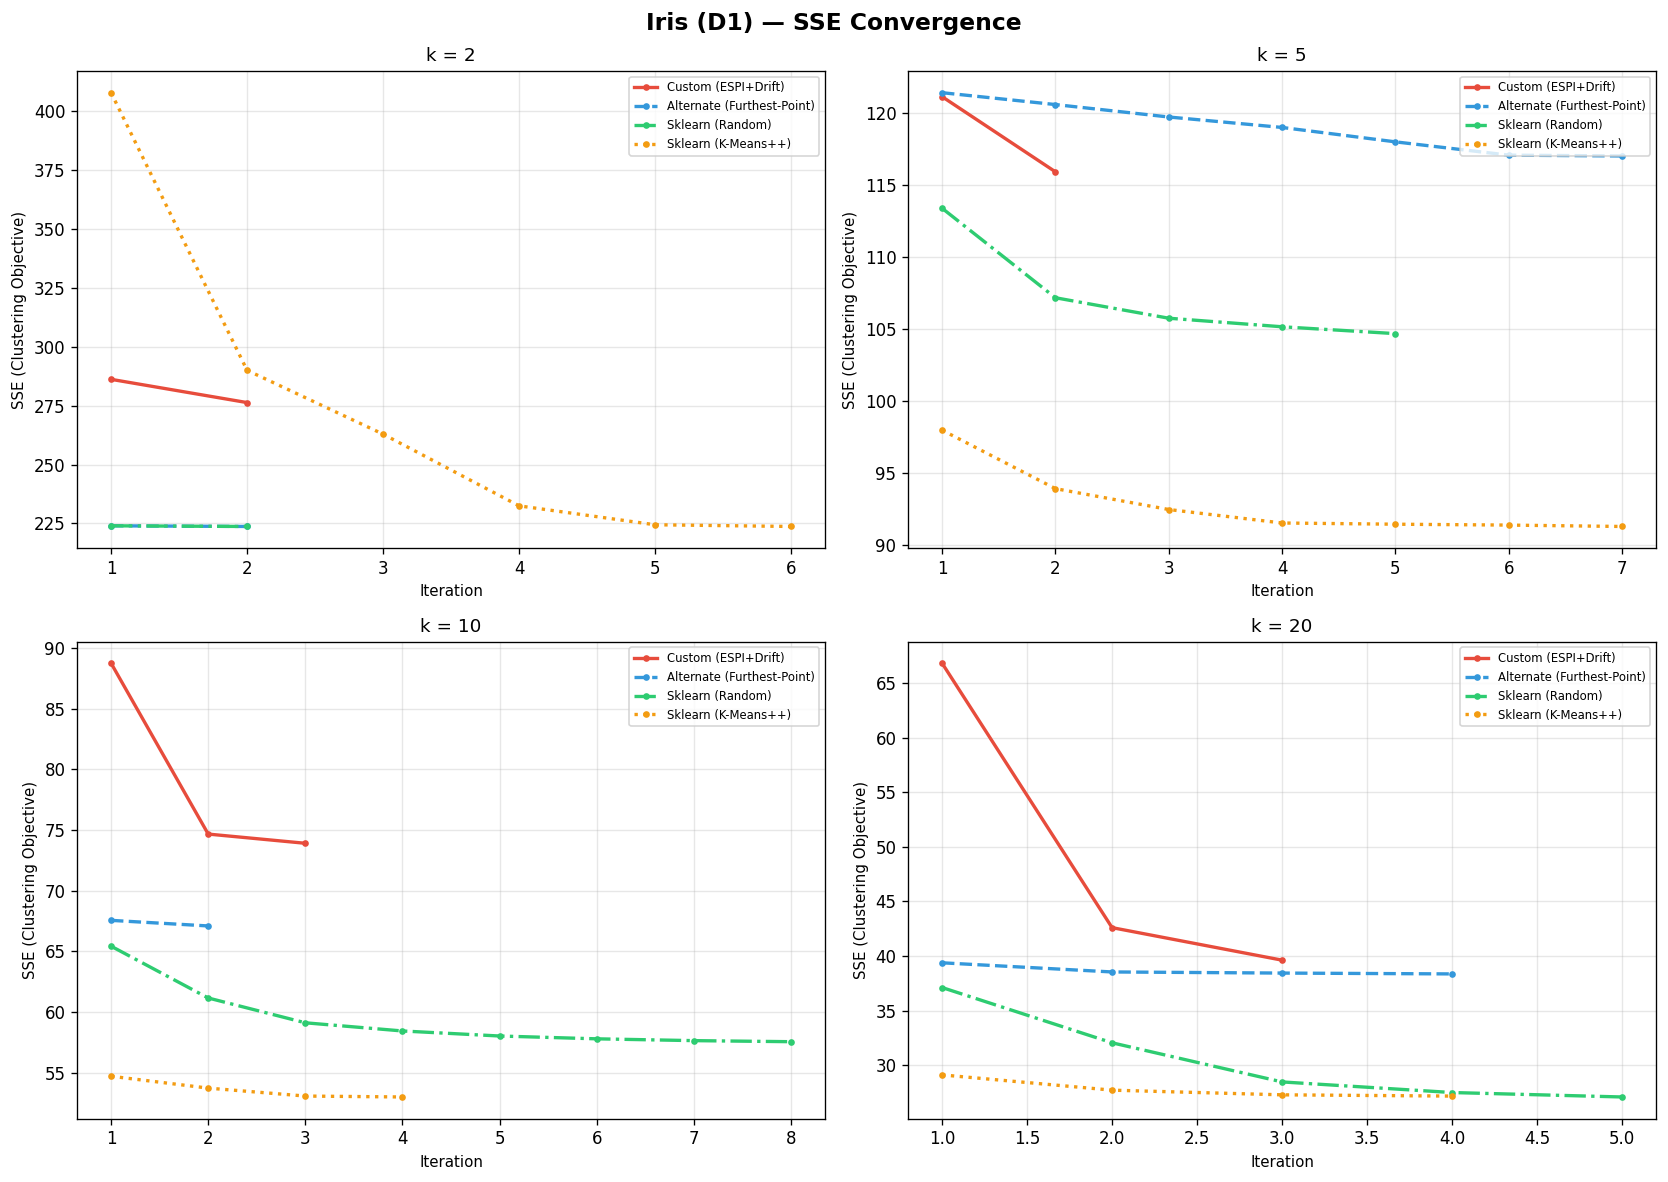

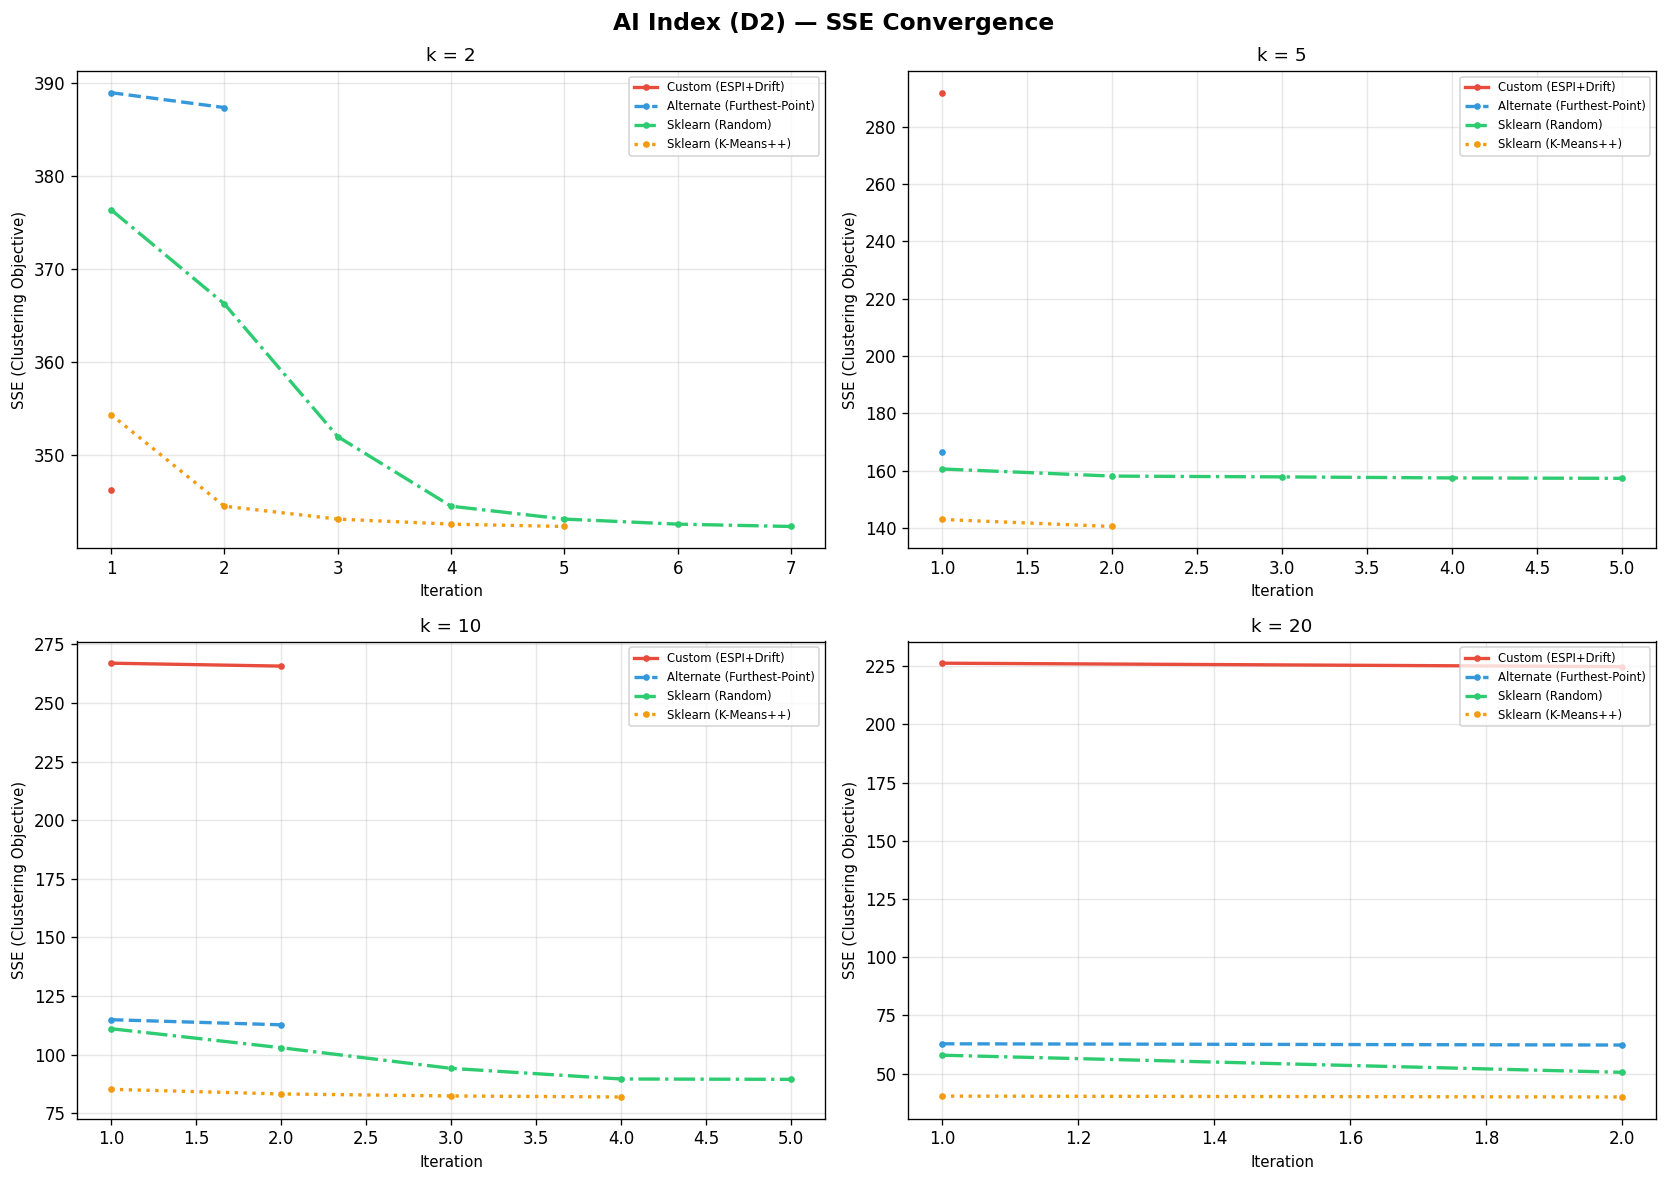

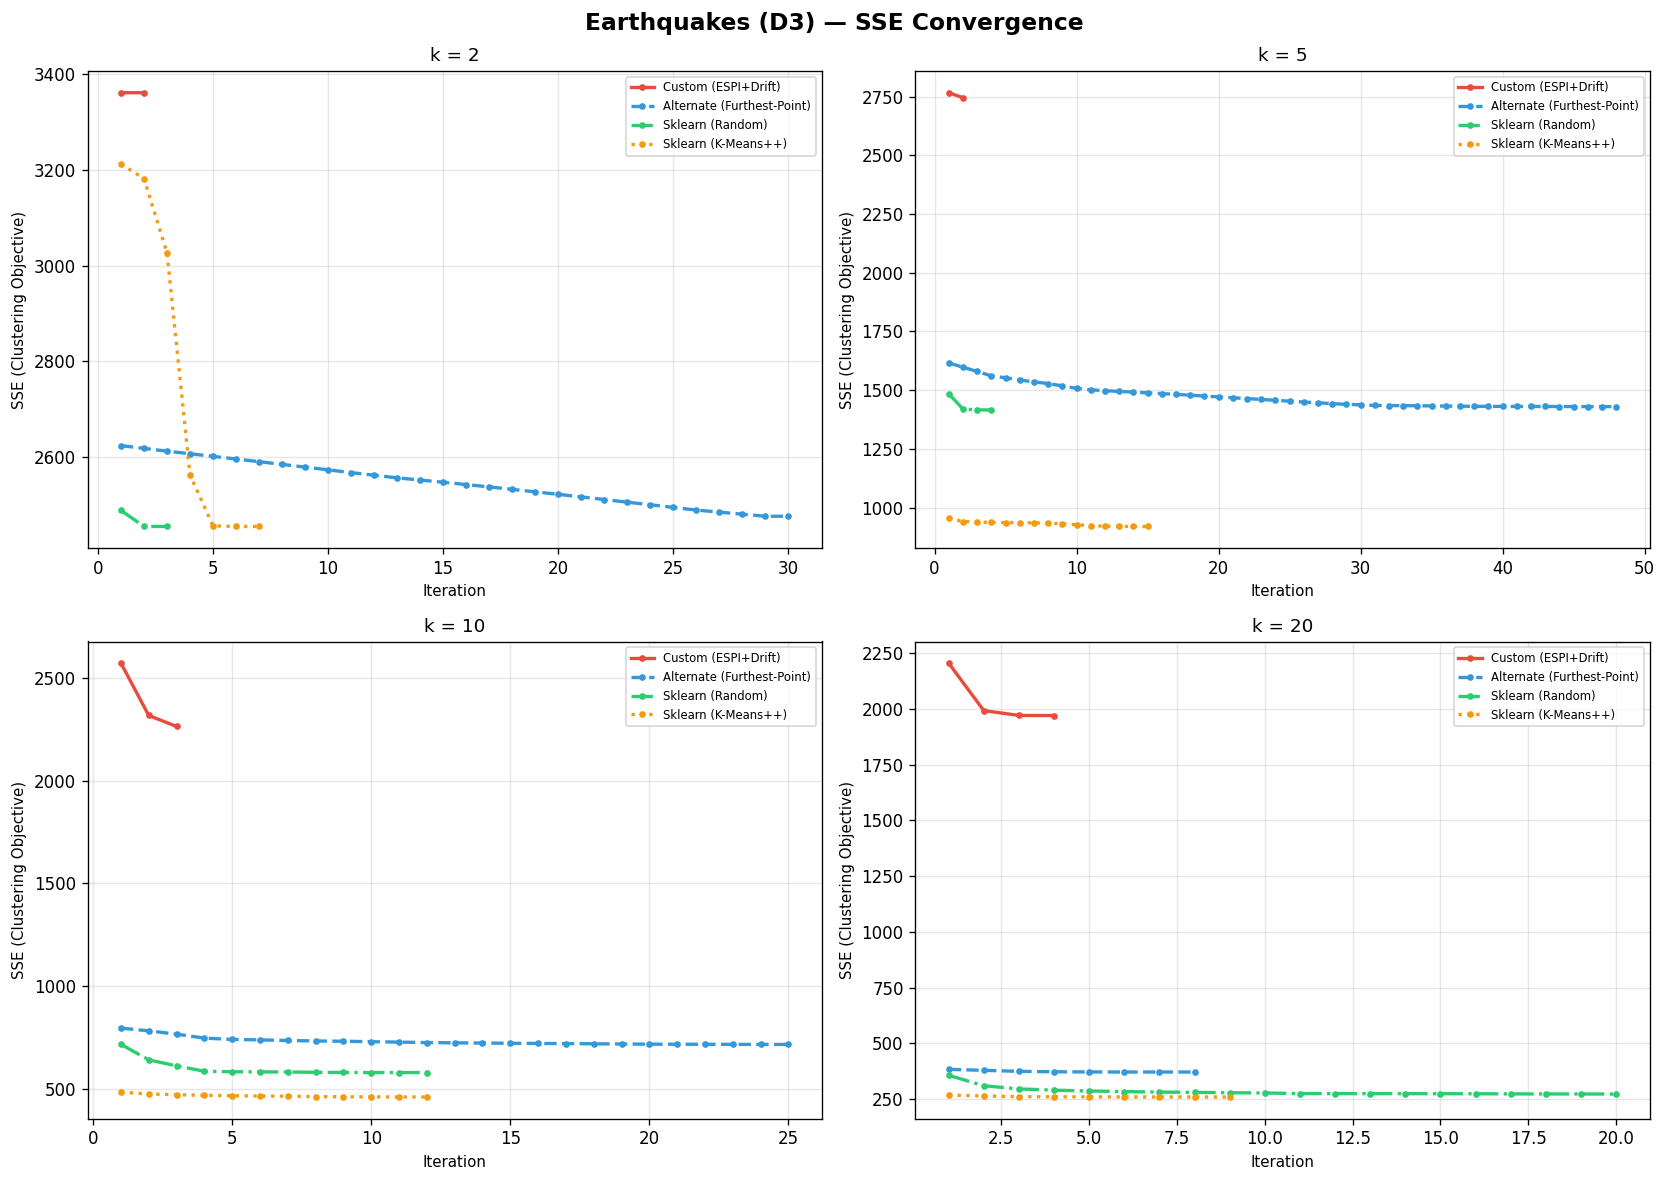

In [5]:
# ── Cell 8: SSE convergence curves ───────────────────────────────────────────
line_styles = ['-', '--', '-.', ':']

for ds_name in datasets:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{ds_name} — SSE Convergence', fontsize=14, fontweight='bold')

    for ax_idx, k in enumerate(k_values):
        ax = axes[ax_idx // 2, ax_idx % 2]

        for algo_idx in range(4):
            res = all_results[(ds_name, k, algo_idx)]
            sse_hist = res['sse_history']
            iters = list(range(1, len(sse_hist) + 1))
            ax.plot(iters, sse_hist,
                    color=algo_colors[algo_idx],
                    linestyle=line_styles[algo_idx],
                    linewidth=2,
                    marker='o', markersize=3,
                    label=algo_names[algo_idx])

        ax.set_title(f'k = {k}', fontsize=11)
        ax.set_xlabel('Iteration', fontsize=9)
        ax.set_ylabel('SSE (Clustering Objective)', fontsize=9)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

## 4.2.3 Stability of Cluster Assignments

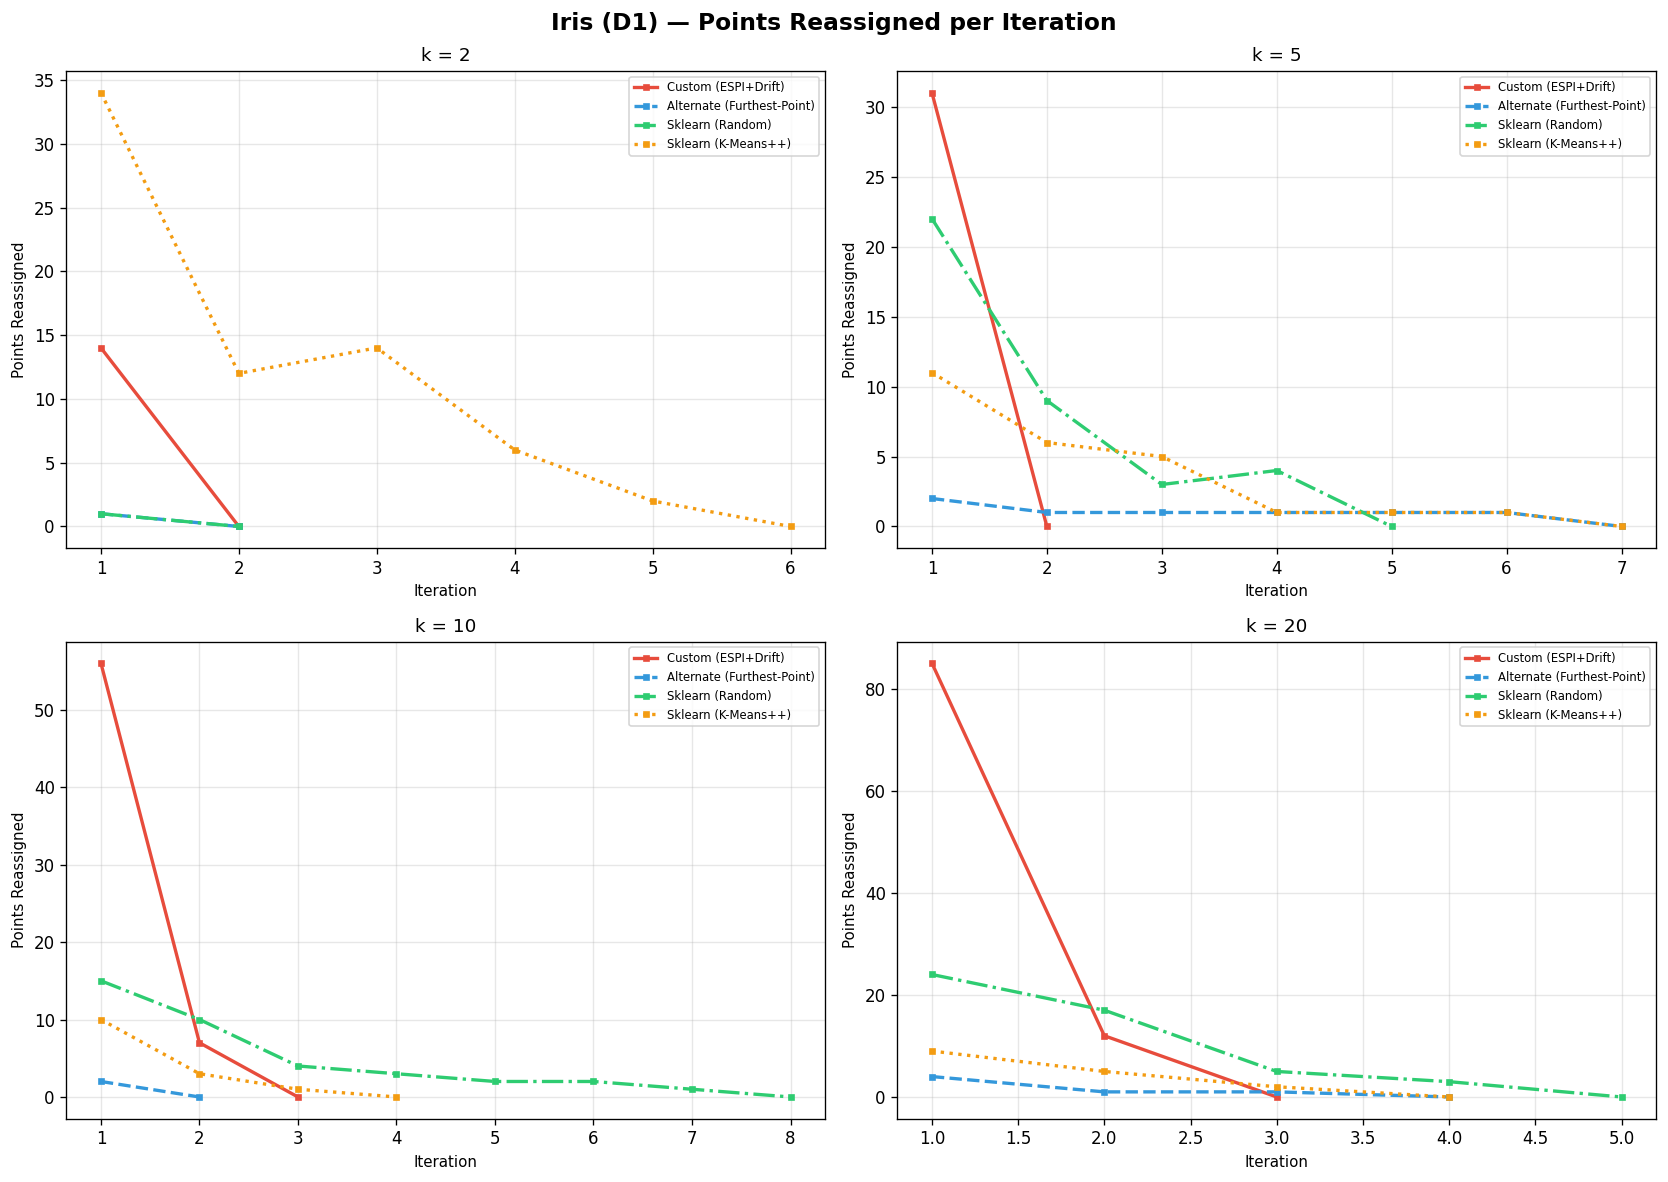

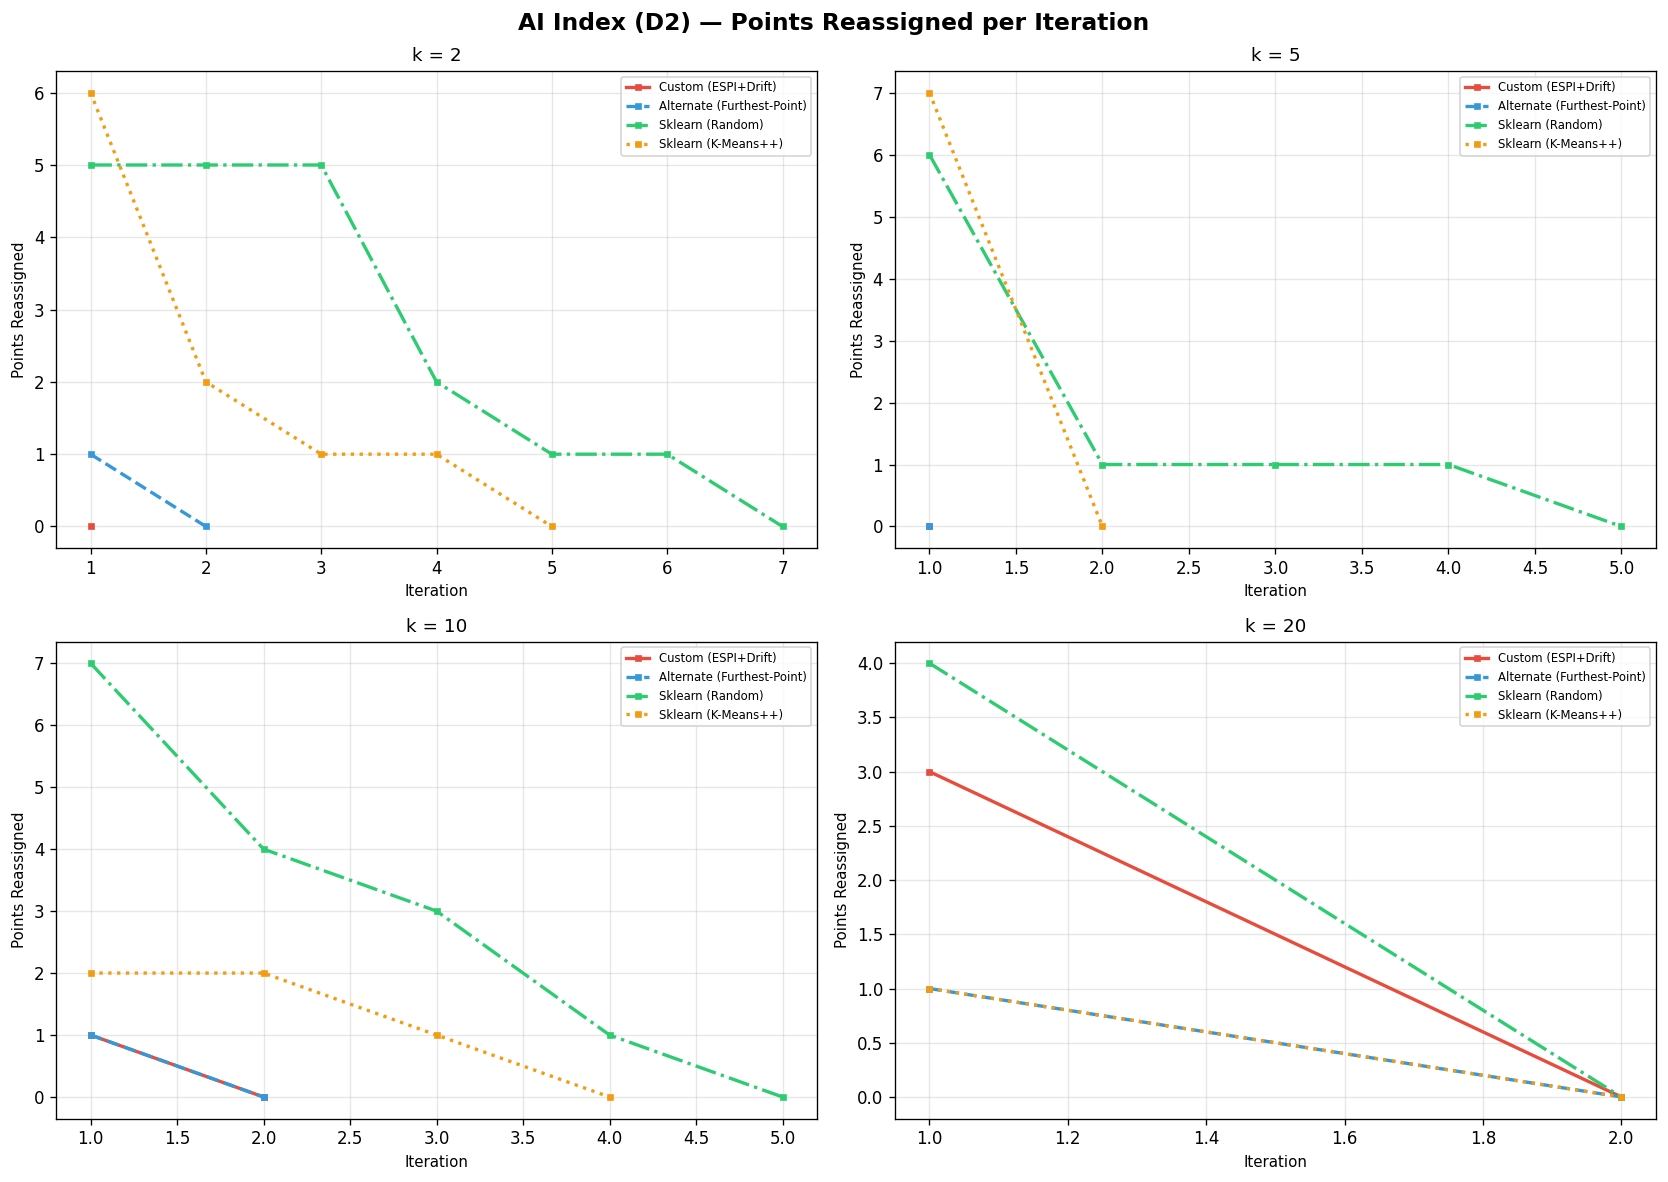

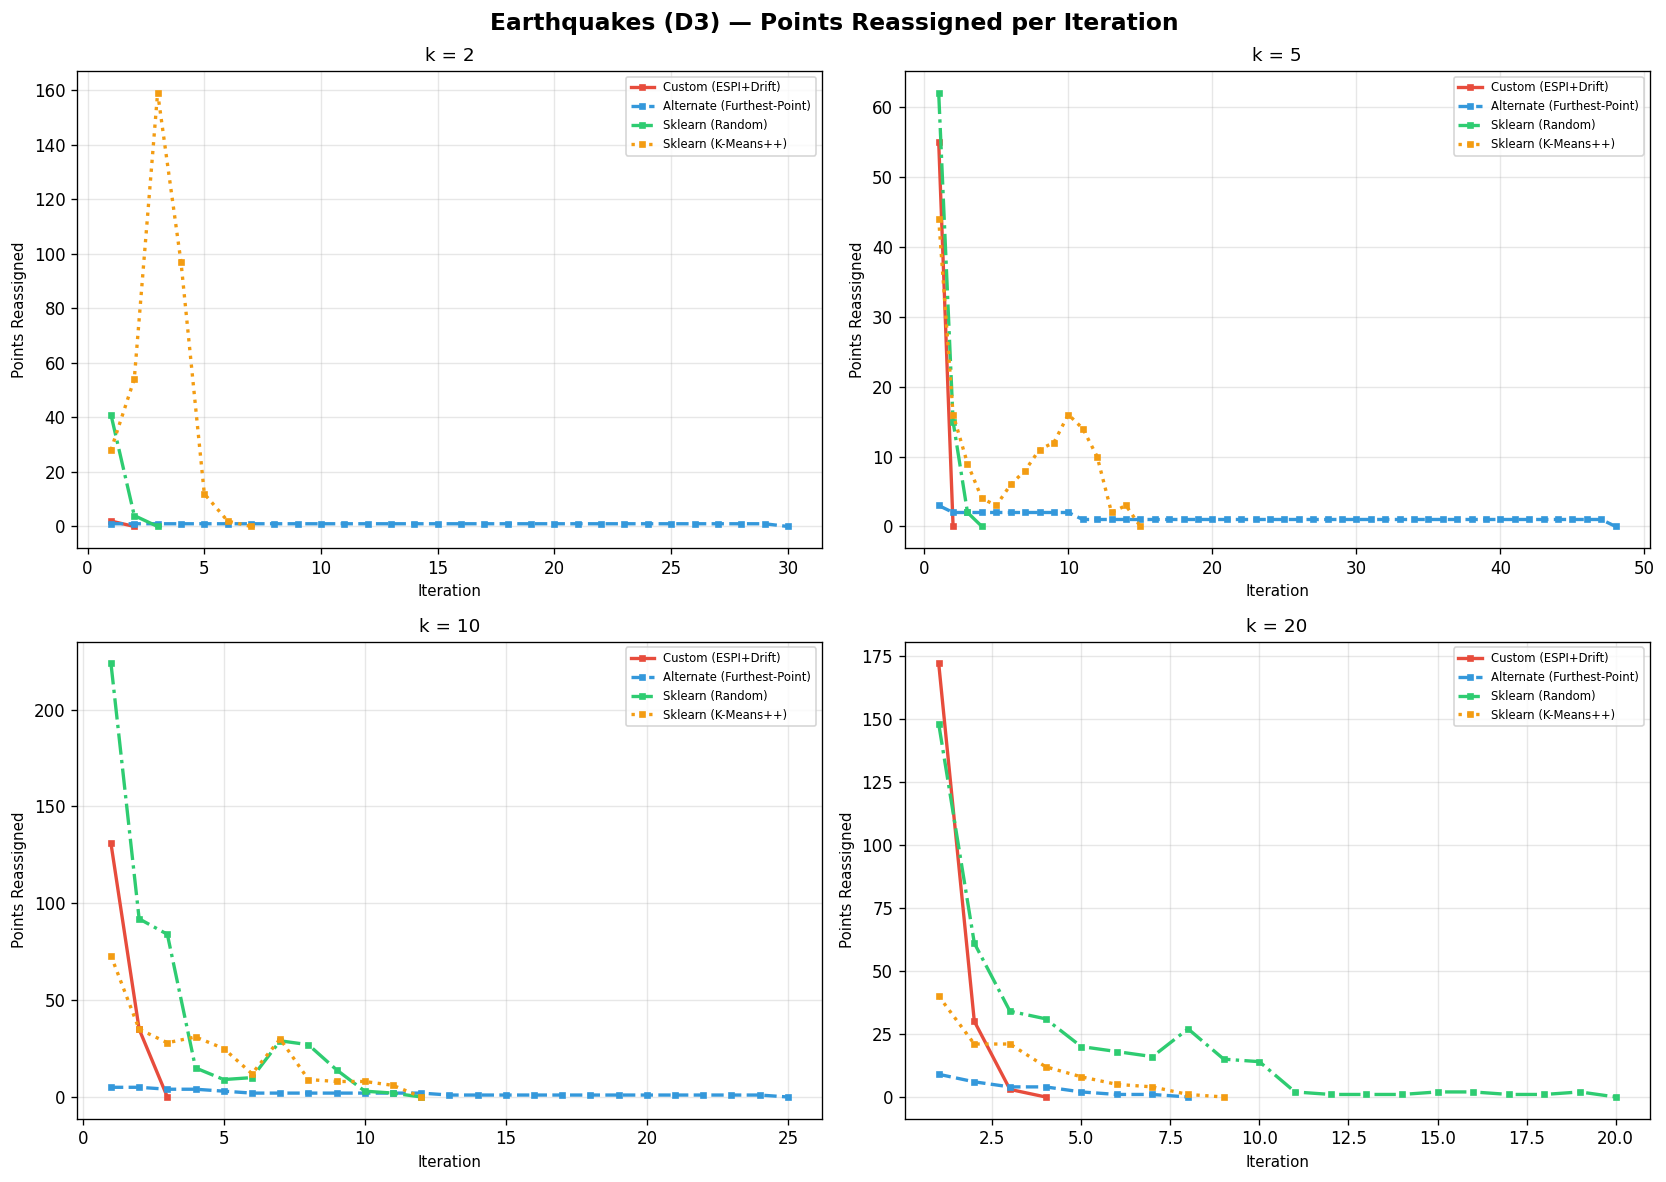

In [6]:
# ── Cell 10: Points reassigned per iteration ─────────────────────────────────
for ds_name in datasets:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{ds_name} — Points Reassigned per Iteration',
                 fontsize=14, fontweight='bold')

    for ax_idx, k in enumerate(k_values):
        ax = axes[ax_idx // 2, ax_idx % 2]

        for algo_idx in range(4):
            res = all_results[(ds_name, k, algo_idx)]
            reassigned = res['reassigned_history']
            iters = list(range(1, len(reassigned) + 1))
            ax.plot(iters, reassigned,
                    color=algo_colors[algo_idx],
                    linestyle=line_styles[algo_idx],
                    linewidth=2,
                    marker='s', markersize=3,
                    label=algo_names[algo_idx])

        ax.set_title(f'k = {k}', fontsize=11)
        ax.set_xlabel('Iteration', fontsize=9)
        ax.set_ylabel('Points Reassigned', fontsize=9)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

## 4.2.4 Runtime Comparison

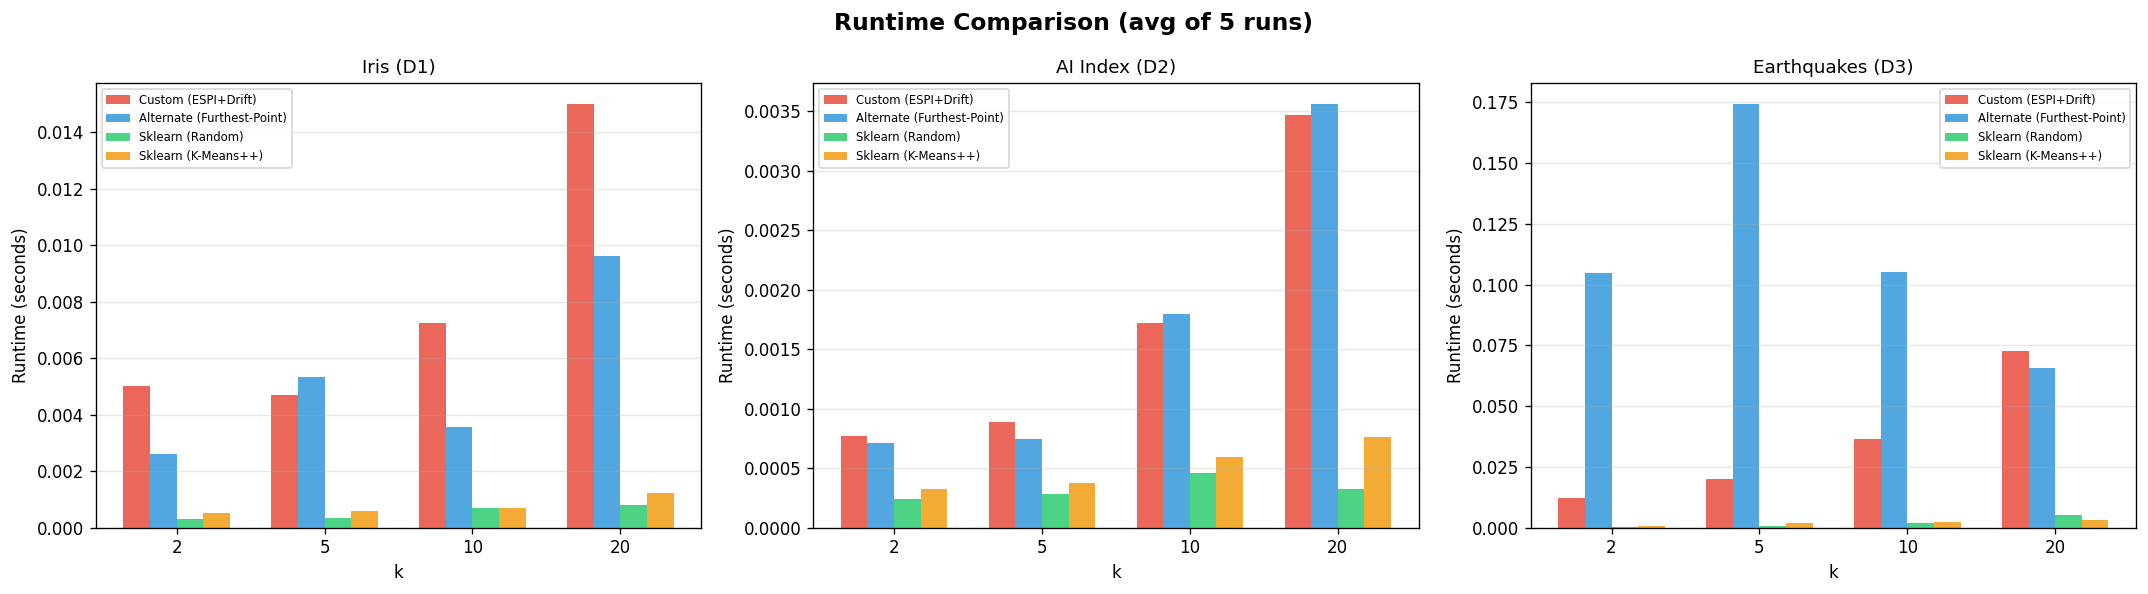


── Runtime Summary Table (seconds) ──


Algorithm            Custom (ESPI+Drift)  Alternate (Furthest-Point)  \
Dataset          k                                                     
AI Index (D2)    2               0.00077                     0.00071   
                 5               0.00089                     0.00075   
                 10              0.00172                     0.00179   
                 20              0.00346                     0.00356   
Earthquakes (D3) 2               0.01241                     0.10498   
                 5               0.01987                     0.17425   
                 10              0.03662                     0.10532   
                 20              0.07275                     0.06555   
Iris (D1)        2               0.00500                     0.00260   
                 5               0.00468                     0.00534   
                 10              0.00725                     0.00357   
                 20              0.01500                     0.00961   

Algorithm            Sklearn (Random)  Sklearn (K-Means++)  
Dataset          k                                          
AI Index (D2)    2            0.00024              0.00032  
                 5            0.00028              0.00038  
                 10           0.00046              0.00060  
                 20           0.00033              0.00076  
Earthquakes (D3) 2            0.00030              0.00080  
                 5            0.00051              0.00193  
                 10           0.00188              0.00243  
                 20           0.00520              0.00332  
Iris (D1)        2            0.00032              0.00050  
                 5            0.00036              0.00059  
                 10           0.00068              0.00069  
                 20           0.00081              0.00122

In [7]:
# ── Cell 12: Runtime benchmarks (5 runs avg) + grouped bar chart ─────────────
n_runs = 5
runtime_records = []

for ds_name, data in datasets.items():
    for k in k_values:
        # ---- Custom (ESPI+Drift) ----
        times_custom = []
        for _ in range(n_runs):
            m = KMeansCustom(k=k, max_iterations=100, epsilon=1e-4)
            t0 = time.perf_counter()
            m.fit(data)
            times_custom.append(time.perf_counter() - t0)
        runtime_records.append({'Dataset': ds_name, 'k': k,
                                'Algorithm': algo_names[0],
                                'Runtime (s)': np.mean(times_custom)})

        # ---- Alternate (Furthest-Point) ----
        times_alt = []
        for r in range(n_runs):
            np.random.seed(42)
            m = KMeansAlternate(k=k, max_iterations=100)
            t0 = time.perf_counter()
            m.fit(data)
            times_alt.append(time.perf_counter() - t0)
        runtime_records.append({'Dataset': ds_name, 'k': k,
                                'Algorithm': algo_names[1],
                                'Runtime (s)': np.mean(times_alt)})

        # ---- Sklearn Random ----
        times_rnd = []
        for _ in range(n_runs):
            m = StandardKMeansTracker(k=k, init='random', random_state=42)
            t0 = time.perf_counter()
            m.fit(data)
            times_rnd.append(time.perf_counter() - t0)
        runtime_records.append({'Dataset': ds_name, 'k': k,
                                'Algorithm': algo_names[2],
                                'Runtime (s)': np.mean(times_rnd)})

        # ---- Sklearn K-Means++ ----
        times_kpp = []
        for _ in range(n_runs):
            m = StandardKMeansTracker(k=k, init='k-means++', random_state=42)
            t0 = time.perf_counter()
            m.fit(data)
            times_kpp.append(time.perf_counter() - t0)
        runtime_records.append({'Dataset': ds_name, 'k': k,
                                'Algorithm': algo_names[3],
                                'Runtime (s)': np.mean(times_kpp)})

runtime_df = pd.DataFrame(runtime_records)

# ── Grouped bar chart: 1 row x 3 cols ────────────────────────────────────────
ds_names_list = list(datasets.keys())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Runtime Comparison (avg of 5 runs)', fontsize=14, fontweight='bold')

bar_width = 0.18
x_pos = np.arange(len(k_values))

for col_idx, ds_name in enumerate(ds_names_list):
    ax = axes[col_idx]
    ds_df = runtime_df[runtime_df['Dataset'] == ds_name]

    for algo_idx, aname in enumerate(algo_names):
        algo_df = ds_df[ds_df['Algorithm'] == aname]
        runtimes = algo_df.sort_values('k')['Runtime (s)'].values
        offset = (algo_idx - 1.5) * bar_width
        ax.bar(x_pos + offset, runtimes, bar_width,
               label=aname, color=algo_colors[algo_idx], alpha=0.85)

    ax.set_title(ds_name, fontsize=11)
    ax.set_xlabel('k', fontsize=10)
    ax.set_ylabel('Runtime (seconds)', fontsize=10)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(k_values)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
pivot = runtime_df.pivot_table(index=['Dataset', 'k'],
                               columns='Algorithm',
                               values='Runtime (s)')
pivot = pivot[algo_names]  # reorder columns
print('\n── Runtime Summary Table (seconds) ──')
display(pivot.round(5))

## 4.3 Analysis and Discussion

### 4.3.1 Potential Advantages

**Custom (ESPI + Drift)**
- **Deterministic initialization**: ESPI places centroids along the dominant variance axis using evenly-spaced range segments. There is no randomness, so repeated runs on the same data always produce identical results.
- **O(n*d) initialization cost**: No sorting or pairwise distance computation is needed; only a single pass to find the variance, min, and max along the dominant dimension.
- **Drift-based skipping**: After centroids are updated, the algorithm computes how far each centroid moved (drift). Points whose distance to their assigned centroid is much larger than twice the drift are provably stable by the triangle inequality and are skipped entirely. This reduces the number of distance computations in later iterations when centroids stabilize.
- **Good initial spread**: By placing centroids at the midpoints of equal-width segments along the highest-variance axis, the algorithm achieves broad initial coverage of the data distribution.

**Alternate (Furthest-Point)**
- **Very conservative reassignment**: Only one point per cluster (the furthest from its centroid) is considered for reassignment each iteration. This prevents drastic label shifts and large SSE oscillations.
- **Potentially more stable SSE descent**: Because at most k points move per iteration, the SSE curve tends to decrease smoothly and monotonically, without the jumps seen in full-reassignment methods.
- **Natural outlier handling**: The furthest point in a cluster is often an outlier or a point on the boundary; reassigning it first means outliers are redistributed before well-placed points are disturbed.

**Sklearn (Random)**
- **Baseline simplicity**: Random initialization is the simplest approach with zero computational overhead. It serves as a useful baseline to evaluate more sophisticated methods.
- **Fast initialization**: Selecting k random data points is O(k), making it the cheapest possible initialization.

**Sklearn (K-Means++)**
- **Smart initialization**: K-means++ selects initial centroids with probability proportional to squared distance from existing centroids. This leads to a better initial SSE and, on average, better final clustering quality.
- **Fewer iterations to converge**: The superior starting configuration often means the algorithm reaches convergence in fewer iterations than random initialization.
- **Theoretical guarantees**: K-means++ provides an O(log k) approximation guarantee on the optimal SSE, which random initialization lacks.

### 4.3.2 Possible Drawbacks

**Custom (ESPI + Drift)**
- **Single-dimension dependency**: ESPI initialization only uses the dominant variance axis for centroid spread. When variance is evenly distributed across dimensions (e.g., isotropic data), the initialization may not provide good coverage of the data cloud. In the worst case, multiple centroids could project to nearby regions in the non-dominant dimensions.
- **Drift threshold is a hyperparameter**: The epsilon parameter controls when convergence is declared. A poorly chosen epsilon may cause premature termination (too large) or unnecessary iterations (too small). This adds tuning complexity compared to parameter-free methods.
- **Drift skipping can miss moves**: In edge cases where many centroids move simultaneously in complex ways, the triangle inequality bound may be too loose, and the algorithm could delay beneficial reassignments.

**Alternate (Furthest-Point)**
- **Very slow convergence**: Because only one point per cluster moves per iteration, the algorithm may need O(n) iterations before all points are correctly assigned. For large datasets, this can be prohibitively slow.
- **Per-iteration cost remains O(n*k*d)**: Even though only k points are reassigned, the algorithm must still scan all points in each cluster to find the furthest one, plus compute distances from that point to all centroids.
- **Can get stuck**: If the furthest point in each cluster is already closest to its own centroid (even if other non-furthest points would benefit from moving), the algorithm converges prematurely with a suboptimal solution.
- **Random initialization sensitivity**: Like standard random init, the final quality depends on the initial centroid selection.

**Sklearn (Random)**
- **Sensitive to random seed**: The initial centroid positions are entirely determined by the random seed. Poor seeds can place centroids in the same cluster, leading to poor convergence and high final SSE.
- **May converge to poor local minima**: Without any intelligence in the initialization, the algorithm is more likely to find a local optimum far from the global one.
- **No reproducibility guarantee across different seeds**: Two runs with different seeds can produce vastly different clusterings.

**Sklearn (K-Means++)**
- **Initialization cost is O(n*k*d)**: K-means++ requires k sequential passes through the data, computing distances to already-selected centroids. For large n and k, this overhead can be significant.
- **Still non-deterministic**: While the initialization is smarter than random, it still involves random sampling (weighted by distance), so results vary across runs.
- **Diminishing returns for large k**: As k grows, the initialization advantage over random diminishes because even random selection tends to cover the data space adequately.

### 4.3.3 When the Alternate Algorithm Might Be Preferred

1. **When stability is paramount**: The gradual, one-point-per-cluster reassignment strategy prevents the large SSE oscillations and drastic label shifts that can occur with full reassignment. In applications where cluster labels must change smoothly (e.g., real-time tracking systems), this property is valuable.

2. **When outlier sensitivity matters**: By always targeting the furthest (worst-fit) point in each cluster, the algorithm naturally redistributes outliers first. If the goal is to ensure that extreme data points find appropriate homes before refining the core cluster structure, this approach is well-suited.

3. **Small datasets where convergence speed is acceptable**: For datasets with a small number of points (e.g., n < 200), the slow convergence of the alternate algorithm is tolerable because each iteration is cheap in absolute terms. The stability benefits may outweigh the iteration count overhead.

4. **When approximate clustering is sufficient**: If the application does not require the absolute best SSE but rather a stable, reasonable partition (e.g., as a preprocessing step for another algorithm), the alternate approach provides reliable, non-oscillating convergence.

5. **Exploratory analysis with visualization**: The gradual evolution of clusters can be informative when visualizing how the clustering forms, making it a useful pedagogical or exploratory tool.

### 4.3.4 When the Custom Algorithm Might Be Preferred Over K-Means++

1. **When deterministic results are needed**: ESPI initialization is entirely deterministic — no random sampling is involved. Given the same data and k, it always produces the same initial centroids and, consequently, the same final clustering. This is critical for applications requiring reproducibility without fixing random seeds (e.g., regulated industries, auditable pipelines).

2. **When the dataset has a clear dominant variance axis**: If one feature carries substantially more variance than others (e.g., a financial dataset with one variable spanning orders of magnitude), ESPI leverages this structure directly. Placing centroids along this axis ensures initial coverage where the data actually varies, rather than relying on probabilistic coverage.

3. **When initialization speed matters**: ESPI initialization runs in O(n*d) time — a single pass to compute per-dimension variance, then O(k) to place centroids. K-means++ requires k sequential passes through the full dataset (O(n*k*d) total). For large n and k, this difference can be significant. The drift-based skipping in subsequent iterations further reduces the per-iteration cost.

4. **When reproducibility across runs matters**: Because ESPI is deterministic, results are identical across runs without needing to fix a random seed. K-means++ requires explicit seed management to achieve reproducibility, and different software implementations may not produce the same results even with the same seed.

5. **Large datasets where O(n*k*d) initialization cost becomes significant**: For datasets with millions of points and moderate k, the sequential nature of k-means++ initialization (each centroid selection requires a full pass through the data) can become a bottleneck. ESPI's O(n*d) initialization avoids this scaling issue entirely.